# Exploratory Data Analysis - MIDI Dataset
This notebook performs comprehensive EDA on the train, test, and validation MIDI datasets from the `data/processed` directory.

## 1. Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load Datasets from data/processed

In [16]:
# Get the data directory
data_dir = Path('../data/processed')

# Load datasets
train_dir = data_dir / 'train'
test_dir = data_dir / 'test'
validation_dir = data_dir / 'validation'

# Load MIDI files from each directory
def load_midi_filenames(directory):
    """Load all MIDI filenames from a directory"""
    if not directory.exists():
        print(f"Directory not found: {directory}")
        return pd.DataFrame()
    
    midi_files = list(directory.glob('*.midi')) + list(directory.glob('*.mid'))
    filenames = [f.name for f in midi_files]
    return pd.DataFrame({'filename': filenames})

# Load all three datasets
train_data = load_midi_filenames(train_dir)
test_data = load_midi_filenames(test_dir)
validation_data = load_midi_filenames(validation_dir)

print(f"✓ Train dataset loaded: {len(train_data)} files")
print(f"✓ Test dataset loaded: {len(test_data)} files")
print(f"✓ Validation dataset loaded: {len(validation_data)} files")

✓ Train dataset loaded: 962 files
✓ Test dataset loaded: 177 files
✓ Validation dataset loaded: 137 files


## 3. Display Sample Data - TRAIN SET

In [4]:
print("=" * 60)
print("TRAIN SET - Sample Data (First 10 files)")
print("=" * 60)
print(train_data.head(10))
print(f"\nTotal rows: {len(train_data)}")

TRAIN SET - Sample Data (First 10 files)
                                            filename
0  MIDI-Unprocessed_XP_21_R1_2004_02_ORIG_MID--AU...
1  MIDI-Unprocessed_15_R1_2009_03-06_ORIG_MID--AU...
2  MIDI-Unprocessed_XP_15_R2_2004_01_ORIG_MID--AU...
3  MIDI-Unprocessed_19_R1_2011_MID--AUDIO_R1-D7_1...
4  MIDI-Unprocessed_083_PIANO083_MID--AUDIO-split...
5  MIDI-Unprocessed_XP_04_R1_2004_01-02_ORIG_MID-...
6  MIDI-Unprocessed_09_R1_2008_01-05_ORIG_MID--AU...
7  MIDI-UNPROCESSED_21-22_R1_2014_MID--AUDIO_21_R...
8  MIDI-Unprocessed_11_R1_2009_01-05_ORIG_MID--AU...
9  MIDI-Unprocessed_24_R1_2006_01-05_ORIG_MID--AU...

Total rows: 962


## 4. Display Sample Data - TEST SET

In [5]:
print("=" * 60)
print("TEST SET - Sample Data (First 10 files)")
print("=" * 60)
print(test_data.head(10))
print(f"\nTotal rows: {len(test_data)}")

TEST SET - Sample Data (First 10 files)
                                            filename
0  MIDI-Unprocessed_Recital5-7_MID--AUDIO_06_R1_2...
1  MIDI-Unprocessed_07_R1_2006_01-04_ORIG_MID--AU...
2  MIDI-Unprocessed_17_R2_2008_01-04_ORIG_MID--AU...
3  MIDI-Unprocessed_Recital16_MID--AUDIO_16_R1_20...
4  MIDI-Unprocessed_12_R1_2006_01-08_ORIG_MID--AU...
5  MIDI-UNPROCESSED_04-05_R1_2014_MID--AUDIO_04_R...
6  MIDI-Unprocessed_17_R1_2008_01-04_ORIG_MID--AU...
7  MIDI-Unprocessed_R1_D1-1-8_mid--AUDIO-from_mp3...
8  MIDI-UNPROCESSED_01-03_R1_2014_MID--AUDIO_03_R...
9  MIDI-Unprocessed_22_R2_2011_MID--AUDIO_R2-D5_1...

Total rows: 177


## 5. Display Sample Data - VALIDATION SET

In [6]:
print("=" * 60)
print("VALIDATION SET - Sample Data (First 10 files)")
print("=" * 60)
print(validation_data.head(10))
print(f"\nTotal rows: {len(validation_data)}")

VALIDATION SET - Sample Data (First 10 files)
                                            filename
0  MIDI-UNPROCESSED_04-05_R1_2014_MID--AUDIO_05_R...
1  MIDI-Unprocessed_21_R1_2011_MID--AUDIO_R1-D8_1...
2  MIDI-Unprocessed_16_R1_2006_01-04_ORIG_MID--AU...
3  MIDI-Unprocessed_Recital9-11_MID--AUDIO_09_R1_...
4  MIDI-Unprocessed_058_PIANO058_MID--AUDIO-split...
5  MIDI-Unprocessed_073_PIANO073_MID--AUDIO-split...
6  MIDI-UNPROCESSED_14-15_R1_2014_MID--AUDIO_15_R...
7  MIDI-Unprocessed_Recital4_MID--AUDIO_04_R1_201...
8  MIDI-Unprocessed_17_R1_2006_01-06_ORIG_MID--AU...
9  MIDI-Unprocessed_12_R3_2011_MID--AUDIO_R3-D4_0...

Total rows: 137


## 6. Visualize Dataset Sizes - Bar Chart

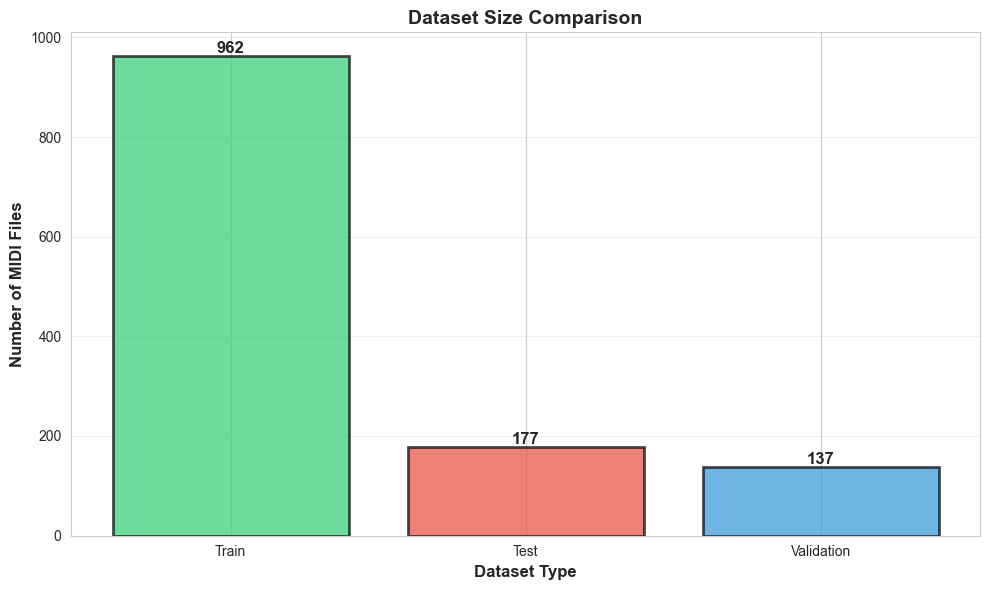


Dataset Size Summary:
  Train:       962 files
  Test:        177 files
  Validation:  137 files
  TOTAL:      1276 files


In [7]:
# Create a bar chart comparing dataset sizes
fig, ax = plt.subplots(figsize=(10, 6))

datasets = ['Train', 'Test', 'Validation']
sizes = [len(train_data), len(test_data), len(validation_data)]
colors = ['#2ecc71', '#e74c3c', '#3498db']

bars = ax.bar(datasets, sizes, color=colors, alpha=0.7, edgecolor='black', linewidth=2)

# Add value labels on bars
for bar, size in zip(bars, sizes):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{int(size)}',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Number of MIDI Files', fontsize=12, fontweight='bold')
ax.set_xlabel('Dataset Type', fontsize=12, fontweight='bold')
ax.set_title('Dataset Size Comparison', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nDataset Size Summary:")
print(f"  Train:      {len(train_data):4d} files")
print(f"  Test:       {len(test_data):4d} files")
print(f"  Validation: {len(validation_data):4d} files")
print(f"  TOTAL:      {len(train_data) + len(test_data) + len(validation_data):4d} files")

## 7. Check for Null Values - TRAIN SET

In [8]:
print("=" * 60)
print("TRAIN SET - Null Values Check")
print("=" * 60)
null_counts = train_data.isnull().sum()
print(null_counts)
print(f"\nTotal null values: {null_counts.sum()}")

if null_counts.sum() == 0:
    print("✓ No null values found in train set!")

TRAIN SET - Null Values Check
filename    0
dtype: int64

Total null values: 0
✓ No null values found in train set!


## 8. Check for Null Values - TEST SET

In [9]:
print("=" * 60)
print("TEST SET - Null Values Check")
print("=" * 60)
null_counts = test_data.isnull().sum()
print(null_counts)
print(f"\nTotal null values: {null_counts.sum()}")

if null_counts.sum() == 0:
    print("✓ No null values found in test set!")

TEST SET - Null Values Check
filename    0
dtype: int64

Total null values: 0
✓ No null values found in test set!


## 9. Check for Null Values - VALIDATION SET

In [10]:
print("=" * 60)
print("VALIDATION SET - Null Values Check")
print("=" * 60)
null_counts = validation_data.isnull().sum()
print(null_counts)
print(f"\nTotal null values: {null_counts.sum()}")

if null_counts.sum() == 0:
    print("✓ No null values found in validation set!")

VALIDATION SET - Null Values Check
filename    0
dtype: int64

Total null values: 0
✓ No null values found in validation set!


## 10. Check for Duplicate Values - TRAIN SET

In [11]:
print("=" * 60)
print("TRAIN SET - Duplicate Values Check")
print("=" * 60)
duplicates = train_data.duplicated().sum()
print(f"Total duplicate rows: {duplicates}")

if duplicates > 0:
    print("\nDuplicate filenames:")
    print(train_data[train_data.duplicated(keep=False)].sort_values('filename'))
else:
    print("✓ No duplicate values found in train set!")

TRAIN SET - Duplicate Values Check
Total duplicate rows: 0
✓ No duplicate values found in train set!


## 11. Check for Duplicate Values - TEST SET

In [12]:
print("=" * 60)
print("TEST SET - Duplicate Values Check")
print("=" * 60)
duplicates = test_data.duplicated().sum()
print(f"Total duplicate rows: {duplicates}")

if duplicates > 0:
    print("\nDuplicate filenames:")
    print(test_data[test_data.duplicated(keep=False)].sort_values('filename'))
else:
    print("✓ No duplicate values found in test set!")

TEST SET - Duplicate Values Check
Total duplicate rows: 0
✓ No duplicate values found in test set!


## 12. Check for Duplicate Values - VALIDATION SET

In [13]:
print("=" * 60)
print("VALIDATION SET - Duplicate Values Check")
print("=" * 60)
duplicates = validation_data.duplicated().sum()
print(f"Total duplicate rows: {duplicates}")

if duplicates > 0:
    print("\nDuplicate filenames:")
    print(validation_data[validation_data.duplicated(keep=False)].sort_values('filename'))
else:
    print("✓ No duplicate values found in validation set!")

VALIDATION SET - Duplicate Values Check
Total duplicate rows: 0
✓ No duplicate values found in validation set!


## 13. Display Dataset Dimensions - All Shapes

In [14]:
print("=" * 60)
print("DATASET DIMENSIONS SUMMARY")
print("=" * 60)

print(f"\nTRAIN SET:")
print(f"  Shape: {train_data.shape}")
print(f"  Rows (Samples): {train_data.shape[0]}")
print(f"  Columns: {train_data.shape[1]}")
print(f"  Column names: {list(train_data.columns)}")

print(f"\nTEST SET:")
print(f"  Shape: {test_data.shape}")
print(f"  Rows (Samples): {test_data.shape[0]}")
print(f"  Columns: {test_data.shape[1]}")
print(f"  Column names: {list(test_data.columns)}")

print(f"\nVALIDATION SET:")
print(f"  Shape: {validation_data.shape}")
print(f"  Rows (Samples): {validation_data.shape[0]}")
print(f"  Columns: {validation_data.shape[1]}")
print(f"  Column names: {list(validation_data.columns)}")

print(f"\n" + "=" * 60)
print("TOTAL DATASET SIZE:")
print("=" * 60)
total_samples = train_data.shape[0] + test_data.shape[0] + validation_data.shape[0]
print(f"Total samples across all splits: {total_samples}")
print(f"Train percentage: {(train_data.shape[0]/total_samples*100):.2f}%")
print(f"Test percentage: {(test_data.shape[0]/total_samples*100):.2f}%")
print(f"Validation percentage: {(validation_data.shape[0]/total_samples*100):.2f}%")

DATASET DIMENSIONS SUMMARY

TRAIN SET:
  Shape: (962, 1)
  Rows (Samples): 962
  Columns: 1
  Column names: ['filename']

TEST SET:
  Shape: (177, 1)
  Rows (Samples): 177
  Columns: 1
  Column names: ['filename']

VALIDATION SET:
  Shape: (137, 1)
  Rows (Samples): 137
  Columns: 1
  Column names: ['filename']

TOTAL DATASET SIZE:
Total samples across all splits: 1276
Train percentage: 75.39%
Test percentage: 13.87%
Validation percentage: 10.74%


## 14. Final Summary - Pie Chart of Data Split

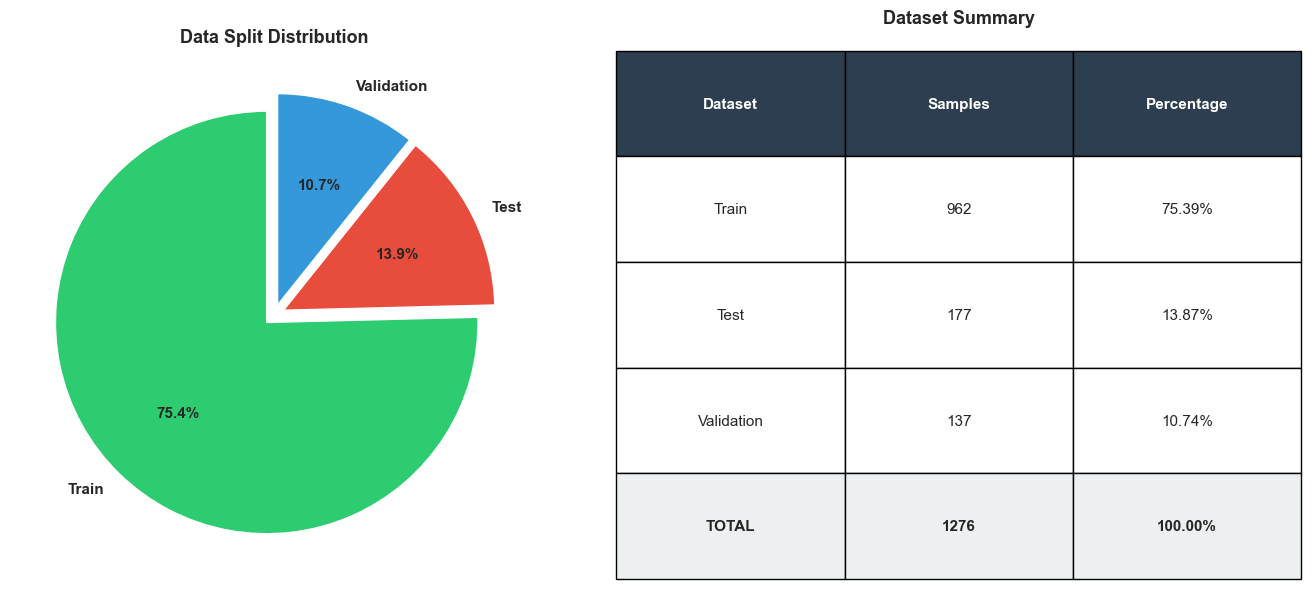


✓ EDA Complete!


In [15]:
# Create a pie chart showing data distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart
sizes = [len(train_data), len(test_data), len(validation_data)]
labels = ['Train', 'Test', 'Validation']
colors = ['#2ecc71', '#e74c3c', '#3498db']
explode = (0.05, 0.05, 0.05)

ax1.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', 
        startangle=90, explode=explode, textprops={'fontsize': 11, 'fontweight': 'bold'})
ax1.set_title('Data Split Distribution', fontsize=13, fontweight='bold')

# Summary table
summary_data = {
    'Dataset': ['Train', 'Test', 'Validation', 'TOTAL'],
    'Samples': [len(train_data), len(test_data), len(validation_data), total_samples],
    'Percentage': [f"{(len(train_data)/total_samples*100):.2f}%", 
                   f"{(len(test_data)/total_samples*100):.2f}%",
                   f"{(len(validation_data)/total_samples*100):.2f}%",
                   "100.00%"]
}

ax2.axis('off')
table = ax2.table(cellText=[[summary_data['Dataset'][i], 
                            str(summary_data['Samples'][i]), 
                            summary_data['Percentage'][i]] for i in range(len(summary_data['Dataset']))],
                  colLabels=['Dataset', 'Samples', 'Percentage'],
                  cellLoc='center',
                  loc='center',
                  colColours=['#f0f0f0']*3,
                  bbox=[0, 0, 1, 1])

table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2)

# Style the header row
for i in range(3):
    table[(0, i)].set_facecolor('#2c3e50')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Style the total row
for i in range(3):
    table[(4, i)].set_facecolor('#ecf0f1')
    table[(4, i)].set_text_props(weight='bold')

ax2.set_title('Dataset Summary', fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
plt.show()

print("\n✓ EDA Complete!")